In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

from xgboost import XGBClassifier
import joblib


In [2]:
df = pd.read_csv("/content/loan_approval_dataset.csv")

# Clean column names
df.columns = df.columns.str.strip().str.replace(" ", "_")

df.head()


,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [3]:
selected_features = [
    "cibil_score",
    "loan_term",
    "loan_amount",
    "income_annum",
    "bank_asset_value",
    "residential_assets_value"
]

X = df[selected_features]
y = df["loan_status"]


In [4]:
y = df['loan_status'].str.strip().map({"Approved":1, "Rejected":0})

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [6]:
model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

model.fit(X_train, y_train)

print("Model Trained ✅")

Model Trained ✅


In [7]:
preds = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, preds))
print("\nReport:\n", classification_report(y_test, preds))

Accuracy: 0.9847775175644028

Report:
               precision    recall  f1-score   support

           0       0.99      0.97      0.98       323
           1       0.98      0.99      0.99       531

    accuracy                           0.98       854
   macro avg       0.99      0.98      0.98       854
weighted avg       0.98      0.98      0.98       854



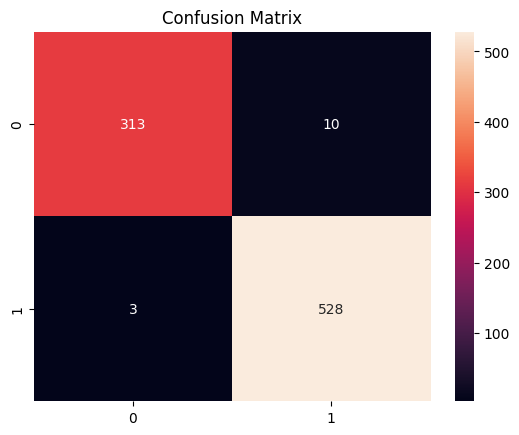

In [8]:
cm = confusion_matrix(y_test, preds)

sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix")
plt.show()

In [14]:
joblib.dump(model, "loan_model_top6.pkl")
print("Model Saved ✅")


Model Saved ✅
